In [2]:
# We start by importing all the necessary packages
import matplotlib.pyplot as plt



In [36]:
import numpy as np
from scipy.integrate import solve_ivp

# Parameters
N = 40          # Grid points (also L96 dimension)
dx = 0.3        # Spatial step
alpha = 0.5
beta = 0.1
F_L96 = 4.0     # L96 forcing

def lorenz96(u):
    """Standard Lorenz-96 tendency."""
    return (np.roll(u, -1) - np.roll(u, 2)) * np.roll(u, 1) - u + F_L96

# def source_s(u):
#     """Source term s(u) — define as needed."""
#     return 0.1 * u  # Example: linear in u

def source_s(u):
    u = np.asarray(u)

    M = np.zeros((len(u), len(u)))

    # find closest indices to 10 and 30
    i1 = 10
    i2 = 30

    M[i1, i1] = 1
    M[i2, i2] = 1

    # print(M)
    
    return M @ ( u**2)
    
    

def advection_upwind(C, u, dx):
    """Upwind advection: -u * dC/dx with periodic BCs."""
    dCdx = np.where(
        u >= 0,
        (C - np.roll(C, 1)) / dx,   # Backward diff for u > 0
        (np.roll(C, -1) - C) / dx   # Forward diff for u < 0
    )
    return -u * dCdx

def rhs(t, y):
    """Right-hand side for the coupled system."""
    C = y[:N]
    u = y[N:]
    
    dCdt = advection_upwind(C, u, dx) + source_s(u) - alpha * C
    dudt = lorenz96(u) - beta * C
    
    return np.concatenate([dCdt, dudt])

# Initial conditions
C0 = np.zeros(N)
u0 = F_L96 * np.ones(N)
u0[0] += 0.01  # Small perturbation
y0 = np.concatenate([C0, u0])

# Integrate
sol = solve_ivp(rhs, [0, 30], y0, method='RK45', max_step=0.01)

C_sol = sol.y[:N, :]
u_sol = sol.y[N:, :]



(40, 3003)


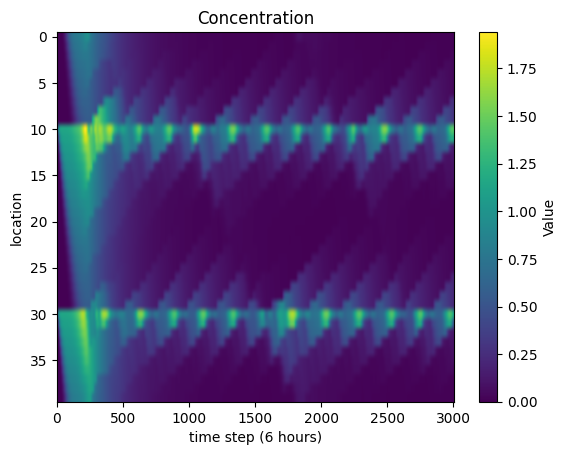

In [37]:
print(C_sol.shape)

plt.imshow(C_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Concentration")
plt.show()

(40, 3003)


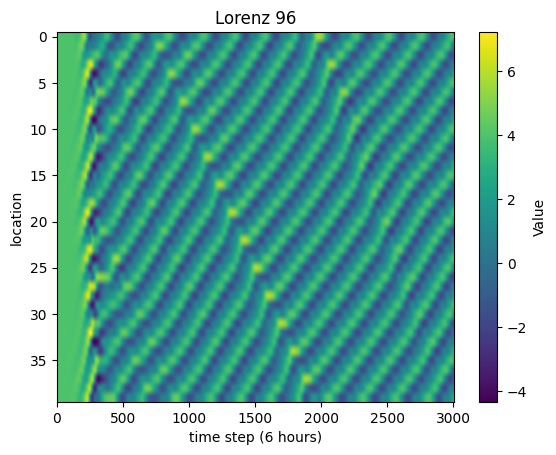

In [38]:
print(u_sol.shape)


plt.imshow(u_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Lorenz 96")
plt.show()